In [35]:
%matplotlib inline

%reload_ext autoreload
%autoreload 2
from notebooks.imports import *

In [36]:
from src.utils import pmf_utils

### Load Configs

In [37]:
from config import dir_config, main_config

compiled_dir = Path(dir_config.data.compiled)
processed_dir = Path(dir_config.data.processed)

psych_model_type = main_config.BEHAVIOR.psych_model

## Load Data

In [38]:
aggregate_data = pd.read_csv(Path(compiled_dir, "aggregate_all_data.csv"), index_col=None)
session_metadata = pd.read_csv(Path(compiled_dir, "aggregate_all_metadata.csv"), encoding='latin1', index_col=None)
session_metadata

,subject_id,gender,age,years_since_diagnosis,pd_meds,is_pd,treatment,off_med_first,MoCA,off_meds_hrs,210_Tremor,212_Balance,213_Freezing,301_Speech,302_Facial_Expression,303a_Rigidity_Neck,303b_Rigidity_RUE,303c_Rigidity_LUE,303d_Rigidity_RLE,303e_Rigidity_LLE,304a_Finger_Tapping_RUE,304b_Finger_Tapping_LUE,305a_Hand_Movements_RUE,305b_Hand_Movements_LUE,306a_Pronation_Supination_Movements_RUE,306b_Pronation_Supination_Movements_LUE,307a_Toe_Tapping_RLE,307b_Toe_Tapping_LLE,308a_Leg_Agility_RLE,308b_Leg_Agility_LLE,309_Arising_from_Chair,310_Gait,311_Freezing_of_Gait,312_Postural_Stability,313_Posture,314_Global_Spontaneity_of_Movement,315a_Postural_Tremor_RUE,315b_Postural_Tremor_LUE,316a_Kinetic_Tremor_RUE,316b_Kinetic_Tremor_LUE,317a_Rest_Tremor_Amplitude_RUE,317b_Rest_Tremor_Amplitude_LUE,317c_Rest_Tremor_Amplitude_RLE,317d_Rest_Tremor_Amplitude_LLE,317e_Rest_Tremor_Amplitude_Lip_Jaw,318_Constancy_of_Rest_Tremor,Were_Diskinesias_Present,Did_these_Movements_Interfere_with_Ratings,Hoehn_and_Yahr_Stage,hands_used,notes,experiment_site
0,P1,M,64.0,7,carbidopa-levodopa (Sinemet) 25-100 mg tablet;...,1,OFF,1.0,NaN,24.00,1.0,1.0,2.0,0.0,1.0,1,0.0,2.0,NaN,NaN,1.0,2.0,1.0,2.0,1.0,2.0,0.0,1.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,no,no,2.0,both,"did not notice red/green bias. In general, squ...",Stanford
1,P1,M,64.0,7,carbidopa-levodopa (Sinemet) 25-100 mg tablet;...,1,ON,1.0,26.0,NaN,NaN,NaN,NaN,0.0,1.0,1,0.0,1.0,1.0,0.0,2.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,no,no,2.0,both,Did not notice red/green bias and squinted eyes,Stanford
2,P3,F,59.0,6,carbidopa-levodopa (Sinemet) 25-100 mg tablet,1,OFF,1.0,27.0,12.50,1.0,0.0,0.0,0.0,1.0,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,no,no,NaN,NaN,NaN,Stanford
3,P3,F,59.0,6,carbidopa-levodopa (Sinemet) 25-100 mg tablet,1,ON,1.0,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,no,no,2.0,NaN,NaN,Stanford
4,P4,M,79.0,3,carbidopa-levodopa (Sinemet CR) 25-100 mg tablet,1,OFF,1.0,29.0,25.00,1.0,0.0,0.0,1.0,3.0,1,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,2.0,NaN,NaN,2.0,NaN,NaN,Stanford
5,P4,M,79.0,3,carbidopa-levodopa (Sinemet CR) 25-100 mg tablet,1,ON,1.0,NaN,NaN,NaN,NaN,NaN,1.0,2.0,1,1.0,2.0,1.0,1.0,1.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,no,no,2.0,NaN,NaN,Stanford
6,P6,M,49.0,3,carbidopa-levodopa (Sinemet) 25-100 mg tablet,1,OFF,1.0,30.0,17.00,1.0,0.0,0.0,0.0,1.0,2,2.0,1.0,2.0,0.0,2.0,0.0,1.0,0.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,1.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,2.0,no,no,2.0,right,Green was easier to see because more contrast ...,Stanford
7,P6,M,49.0,3,carbidopa-levodopa (Sinemet) 25-100 mg tablet,1,ON,1.0,NaN,NaN,NaN,NaN,NaN,0.0,1.0,2,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,no,no,1.0,right,Green was easier to see because more contrast ...,Stanford
8,P7,F,75.0,6,carbidopa-levodopa (Sinemet CR) 25-100 mg tablet,1,OFF,1.0,24.0,13.00,1.0,0.0,0.0,0.0,1.0,0,1.0,1.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,2.0,no,no,NaN,NaN,NaN,Stanford
9,P7,F,75.0,6,carbidopa-levodopa (Sinemet CR) 25-100 mg tablet,1,ON,1.0,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,no,no,1.0,NaN,NaN,Stanford


#### Fill out the subject_metadata prior based on aggregate_data

In [39]:
for subject_id, medication in sorted(list(zip(session_metadata['subject_id'], session_metadata['treatment'])), key = lambda x: x[0]):
    if pd.isna(medication):
        session_data = aggregate_data[(aggregate_data["subject_id"] == subject_id) & aggregate_data["medication"].isna()]
        current_idx = session_metadata[(session_metadata["subject_id"] == subject_id) & session_metadata["treatment"].isna()].index
    else:
        session_data = aggregate_data[(aggregate_data["subject_id"] == subject_id) & (aggregate_data["medication"] == medication.lower())]
        current_idx = session_metadata[(session_metadata["subject_id"] == subject_id) & (session_metadata["treatment"] == medication)].index
    prior = np.unique(session_data["prior"])
    prior = prior[prior != "eq"]

    session_metadata.loc[current_idx, "prior_condition"] = prior[0]
    session_metadata.loc[current_idx, "file_name"] = np.unique(session_data["session_filename"])[0]


In [40]:
import numpy as np

print("Missing values before replacement:")
print(session_metadata.isnull().sum())

# Replace common missing value strings (case-insensitive)
missing_strings = ["", "NA", "NaN", "na", "n/a"]
for ms in missing_strings:
    session_metadata.replace(ms, np.nan, inplace=True)
    session_metadata.replace(ms.upper(), np.nan, inplace=True)
    session_metadata.replace(ms.lower(), np.nan, inplace=True)
    session_metadata.replace(ms.capitalize(), np.nan, inplace=True)

print("\nMissing values after replacement:")
print(session_metadata.isnull().sum())


Missing values before replacement:
subject_id                                     0
gender                                        64
age                                           64
years_since_diagnosis                         64
pd_meds                                       64
is_pd                                          0
treatment                                     10
off_med_first                                 24
MoCA                                          46
off_meds_hrs                                  80
210_Tremor                                    81
212_Balance                                   80
213_Freezing                                  80
301_Speech                                    58
302_Facial_Expression                         58
303a_Rigidity_Neck                            58
303b_Rigidity_RUE                             58
303c_Rigidity_LUE                             58
303d_Rigidity_RLE                             61
303e_Rigidity_LLE                 

In [41]:
print("------------- info ----------------")
print(session_metadata.info())
print("\n\n------------- head ----------------\n\n")
print(session_metadata.head())
print("\n\n------------- describe ----------------\n\n")
print(session_metadata.describe())
print("\n\n------------- dtypes ----------------\n\n")
print(session_metadata.dtypes)
print("\n\n------------- shape ----------------\n\n")
print(session_metadata.shape)

------------- info ----------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 54 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   subject_id                                  110 non-null    object 
 1   gender                                      46 non-null     object 
 2   age                                         46 non-null     float64
 3   years_since_diagnosis                       46 non-null     object 
 4   pd_meds                                     46 non-null     object 
 5   is_pd                                       110 non-null    int64  
 6   treatment                                   100 non-null    object 
 7   off_med_first                               86 non-null     float64
 8   MoCA                                        64 non-null     float64
 9   off_meds_hrs                                30 non-

##### Data rejection

In [42]:
valid_data = aggregate_data[aggregate_data['is_valid'] == 1]
# chose trials with minimum reaction time from main_config
valid_data = valid_data[valid_data['reaction_time'] >= main_config.BEHAVIOR.min_rt]

#### Direction and color conversion to prior condition

In [43]:
# Ensure valid_data is a DataFrame you intend to modify directly
def data_preprocessing(data):

    # remove data from subjects listed in main_config.manual_rejection
    data = data[~data['subject_id'].isin(main_config.moca_rejection)]
    # remove equal prior sessions
    data = data[data['prior'] != 'eq']
    data['prior_color'].loc[data['prior'] == 'eq'] = np.nan
    data['prior_direction'].loc[data['prior'] == 'eq'] = np.nan

    left_prior_idx = data['prior_direction'] == 'left'
    right_prior_idx = data['prior_direction'] == 'right'
    green_prior_idx = data['prior_color'] == 'green'
    red_prior_idx = data['prior_color'] == 'red'

    # Renaming directions based on prior direction
    data.loc[left_prior_idx, 'target'] = data.loc[left_prior_idx, 'target'].map({'left': 1, 'right': 0})
    data.loc[left_prior_idx, 'choice'] = data.loc[left_prior_idx, 'choice'].map({'left': 1, 'right': 0})
    data.loc[right_prior_idx, 'target'] = data.loc[right_prior_idx, 'target'].map({'left': 0, 'right': 1})
    data.loc[right_prior_idx, 'choice'] = data.loc[right_prior_idx, 'choice'].map({'left': 0, 'right': 1})

    # Renaming colors based on prior color
    data.loc[green_prior_idx, 'color'] = data.loc[green_prior_idx, 'color'].map({'green': 1, 'red': 0})
    data.loc[red_prior_idx, 'color'] = data.loc[red_prior_idx, 'color'].map({'green': 0, 'red': 1})

    data['signed_coherence'] = data['coherence'] * (2 * data['target'] - 1)

    return data

valid_data = data_preprocessing(valid_data)
aggregate_data = data_preprocessing(aggregate_data)

#### Data Splicing

In [44]:
slicing = main_config.BEHAVIOR.data_slice

temp_valid_data = pd.DataFrame()
temp_aggregate_data = pd.DataFrame()

if slicing != 0:
	for subject_id, medication in sorted(list(zip(session_metadata['subject_id'], session_metadata['treatment'])), key = lambda x: x[0]):
		# find the corresponding row in the aggregate data
		if pd.isna(medication):
			session_agg_data = aggregate_data[(aggregate_data['subject_id'] == subject_id) & aggregate_data['medication'].isna()]
			session_valid_data = valid_data[(valid_data['subject_id'] == subject_id) & valid_data['medication'].isna()]
		else:
			session_agg_data = aggregate_data[(aggregate_data['subject_id'] == subject_id) & (aggregate_data['medication'] == medication.lower())]
			session_valid_data = valid_data[(valid_data['subject_id'] == subject_id) & (valid_data['medication'] == medication.lower())]

		if session_agg_data.empty or session_valid_data.empty:
			continue

		half = len(session_agg_data) // 2

		if slicing == 1:
			# Take first half
			agg_slice = session_agg_data.iloc[:half]
			valid_slice = session_valid_data.iloc[:half]
		elif slicing == 2:
			# Take second half
			agg_slice = session_agg_data.iloc[half:]
			valid_slice = session_valid_data.iloc[half:]
		else:
			# Use full session if slicing value is unexpected
			agg_slice = session_agg_data
			valid_slice = session_valid_data

		# Concatenate results
		temp_aggregate_data = pd.concat([temp_aggregate_data, agg_slice], ignore_index=True)
		temp_valid_data = pd.concat([temp_valid_data, valid_slice], ignore_index=True)

	aggregate_data = temp_aggregate_data
	valid_data = temp_valid_data

#### Rejecting sessions based on allowed lapse rates

In [45]:
sessions = valid_data['session_filename'].unique()

reject_sessions = []

for session in sessions:
    session_data = valid_data[valid_data['session_filename'] == session]
    accuracy_100prct = np.mean(session_data['outcome'][np.abs(session_data['coherence']) == 100]) * 100
    if accuracy_100prct < main_config.BEHAVIOR.min_easy_accuracy * 100:
        reject_sessions.append(session)
        print(f"Subject: {session} rejected due to low accuracy {accuracy_100prct:.2f}, with session size {len(session_data)}")
        continue

aggregate_data = aggregate_data[~aggregate_data['session_filename'].isin(reject_sessions)]
valid_data = valid_data[~valid_data['session_filename'].isin(reject_sessions)]


Subject: P27_OFFmeds_rl.mat rejected due to low accuracy 33.12, with session size 621
Subject: HC5_healthy_gr.mat rejected due to low accuracy 58.28, with session size 610
Subject: P25_ONmeds_rr.mat rejected due to low accuracy 54.55, with session size 242
Subject: RZA_OFFmeds_gl.mat rejected due to low accuracy 59.21, with session size 599
Subject: RZA_ONmeds_rl.mat rejected due to low accuracy 58.46, with session size 514
Subject: P30_ONmeds_rl.mat rejected due to low accuracy 52.74, with session size 602
Subject: SKU_OFFmeds_rr.mat rejected due to low accuracy 54.11, with session size 592
Subject: HC2_healthy_rl.mat rejected due to low accuracy 46.54, with session size 634
Subject: RSH_ONmeds_gl.mat rejected due to low accuracy 53.19, with session size 556
Subject: P26_ONmeds_gr.mat rejected due to low accuracy 53.90, with session size 626
Subject: AJL_OFFmeds_gr.mat rejected due to low accuracy 52.63, with session size 610
Subject: P26_OFFmeds_gl.mat rejected due to low accuracy 49

In [46]:
print(f"Number of unique subjects in valid_data: {valid_data.subject_id.nunique()} \
      \n{valid_data.subject_id.unique()}")


Number of unique subjects in valid_data: 54       
['HC6' 'P33' 'DMO' 'PAM' 'P1' 'P11' 'BER' 'P13' 'P19' 'BBK' 'FUR' 'LBR'
 'P34' 'P29' 'RBA' 'P6' 'P23' 'DCAM' 'COH' 'HC8' 'P32' 'P31' 'P20' 'P12'
 'LHO' 'MBY' 'CG' 'RDE' 'P18' 'AJL' 'P25' 'P3' 'P24' 'HC7' 'ALE' 'HC9'
 'P7' 'P4' 'SGA' 'DP' 'MAR' 'P9' 'SKU' 'HC13' 'RW' 'P30' 'HC1' 'P28' 'SMI'
 'HC12' 'RSH' 'P22' 'P17' 'HC3']


In [47]:
subject_sessions = valid_data.groupby('subject_id')['medication'].unique()

valid_subjects = []
pd_subjects = []
for subject, sessions in subject_sessions.items():
    sessions_clean = [s for s in sessions if pd.notna(s)]
    if len(sessions_clean) == 0:  # HC subject: no medication
        valid_subjects.append(subject)
    elif set(sessions_clean) == {'on', 'off'}:  # PD subject: both sessions present
        valid_subjects.append(subject)
        pd_subjects.append(subject)
    else:
        print(f"Subject {subject} missing session(s): {sessions}")

aggregate_data = aggregate_data[aggregate_data['subject_id'].isin(valid_subjects)]
valid_data = valid_data[valid_data['subject_id'].isin(valid_subjects)]
valid_session_metadata = session_metadata[session_metadata['subject_id'].isin(valid_subjects)]

hc_subjects = [s for s in valid_subjects if s not in pd_subjects]
print(f"Valid PD subjects: {len(pd_subjects)}, HC subjects: {len(hc_subjects)}, total: {len(valid_subjects)}")
print(valid_subjects)

print("\n\n\n")

# how many pd subjects per experiment site
pd_subjects_by_site = valid_session_metadata[valid_session_metadata['subject_id'].isin(pd_subjects)].groupby('experiment_site')['subject_id'].nunique()
print("PD subjects by site:")
print(pd_subjects_by_site)


Subject AJL missing session(s): ['on']
Subject P25 missing session(s): ['off']
Subject P30 missing session(s): ['off']
Subject RSH missing session(s): ['off']
Subject SKU missing session(s): ['on']
Valid PD subjects: 41, HC subjects: 8, total: 49
['ALE', 'BBK', 'BER', 'CG', 'COH', 'DCAM', 'DMO', 'DP', 'FUR', 'HC1', 'HC12', 'HC13', 'HC3', 'HC6', 'HC7', 'HC8', 'HC9', 'LBR', 'LHO', 'MAR', 'MBY', 'P1', 'P11', 'P12', 'P13', 'P17', 'P18', 'P19', 'P20', 'P22', 'P23', 'P24', 'P28', 'P29', 'P3', 'P31', 'P32', 'P33', 'P34', 'P4', 'P6', 'P7', 'P9', 'PAM', 'RBA', 'RDE', 'RW', 'SGA', 'SMI']




PD subjects by site:
experiment_site
Case_Western     4
Harvard          6
Stanford        16
UCLA            15
Name: subject_id, dtype: int64


### Input decision-behavior parameters into session_metadata

In [48]:
pd_sessions = valid_data[valid_data['medication'].notna()].groupby('subject_id')['medication'].unique()

session_metadata['positive_bias'] = np.nan
session_metadata['positive_psych_alpha'] = np.nan
session_metadata['positive_psych_beta'] = np.nan
session_metadata['positive_psych_lapse'] = np.nan
session_metadata['positive_psych_guess'] = np.nan

session_metadata['equal_psych_bias'] = np.nan
session_metadata['equal_psych_alpha'] = np.nan
session_metadata['equal_psych_beta'] = np.nan
session_metadata['equal_psych_lapse'] = np.nan
session_metadata['equal_psych_guess'] = np.nan

for subject, sessions in pd_sessions.items():
    for session in sessions:
        session_data = valid_data[(valid_data['subject_id'] == subject) & (valid_data['medication'] == session)]
        current_idx = session_metadata[(session_metadata['subject_id'] == subject) & (session_metadata['treatment'] == session.upper())].index

        coh, positive_psych, positive_model, _, _ = pmf_utils.get_psychometric_data(data=session_data[session_data['color'] == 1], model_type=psych_model_type)
        coh, equal_psych, equal_model, _, _ = pmf_utils.get_psychometric_data(data=session_data[session_data['color'] == 0], model_type=psych_model_type)

        session_metadata.loc[current_idx, 'positive_bias'] = positive_psych[3]
        session_metadata.loc[current_idx, 'positive_psych_bias'] = positive_model.predict(0)
        session_metadata.loc[current_idx, 'positive_psych_alpha'] = positive_model.coefs_['mean']
        session_metadata.loc[current_idx, 'positive_psych_beta'] = positive_model.coefs_['var']
        session_metadata.loc[current_idx, 'positive_psych_lapse'] = positive_model.coefs_['lapse_rate']
        session_metadata.loc[current_idx, 'positive_psych_guess'] = positive_model.coefs_['guess_rate']

        session_metadata.loc[current_idx, 'equal_bias'] = equal_psych[3]
        session_metadata.loc[current_idx, 'equal_psych_bias'] = equal_model.predict(0)
        session_metadata.loc[current_idx, 'equal_psych_alpha'] = equal_model.coefs_['mean']
        session_metadata.loc[current_idx, 'equal_psych_beta'] = equal_model.coefs_['var']
        session_metadata.loc[current_idx, 'equal_psych_lapse'] = equal_model.coefs_['lapse_rate']
        session_metadata.loc[current_idx, 'equal_psych_guess'] = equal_model.coefs_['guess_rate']

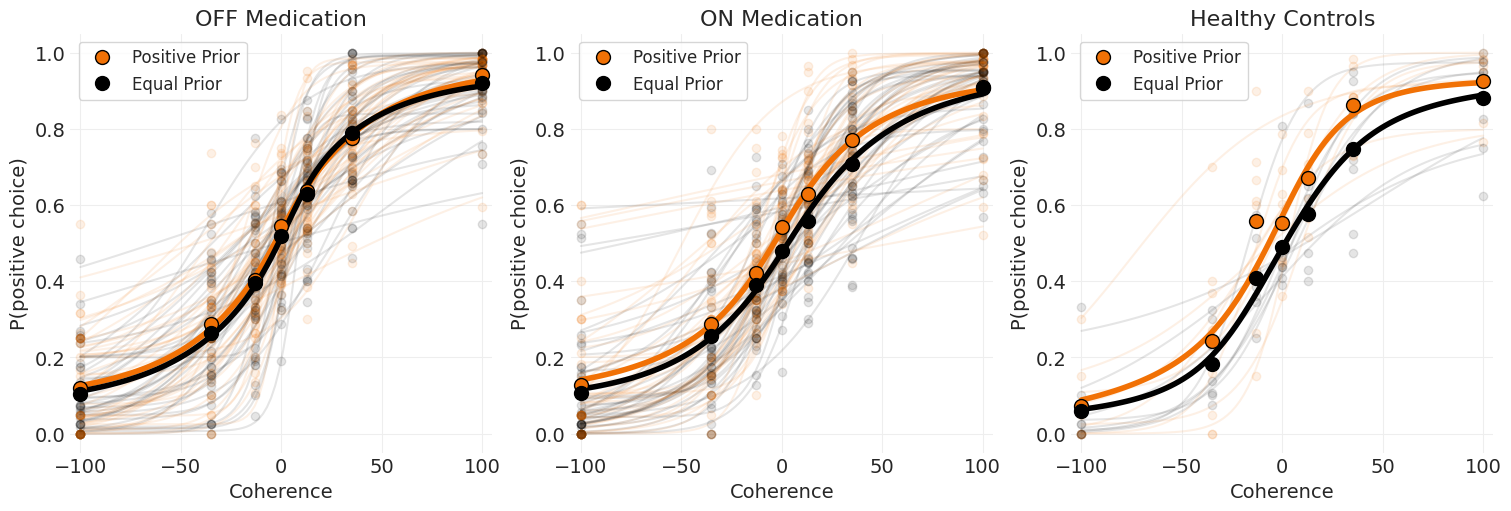

In [49]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
subject_alpha = 0.1
positive_color = 'C5'
equal_color = 'black'

sub_off_pos_coh, sub_off_pos_psych, sub_off_pos_x_hat, sub_off_pos_y_hat = [], [], [], []
sub_off_eq_coh, sub_off_eq_psych, sub_off_eq_x_hat, sub_off_eq_y_hat = [], [], [], []
sub_on_pos_coh, sub_on_pos_psych, sub_on_pos_x_hat, sub_on_pos_y_hat = [], [], [], []
sub_on_eq_coh, sub_on_eq_psych, sub_on_eq_x_hat, sub_on_eq_y_hat = [], [], [], []
sub_hc_pos_coh, sub_hc_pos_psych, sub_hc_pos_x_hat, sub_hc_pos_y_hat = [], [], [], []
sub_hc_eq_coh, sub_hc_eq_psych, sub_hc_eq_x_hat, sub_hc_eq_y_hat = [], [], [], []

for subject in pd_subjects:
    subject_data = valid_data[valid_data['subject_id'] == subject].sort_values('medication')
    for med in subject_data['medication'].unique():
        med_data = subject_data[subject_data['medication'] == med]
        pos_coh, pos_psych, pos_model, pos_x_hat, pos_y_hat = pmf_utils.get_psychometric_data(med_data[med_data['color'] == 1], model_type=psych_model_type)
        eq_coh, eq_psych, eq_model, eq_x_hat, eq_y_hat = pmf_utils.get_psychometric_data(med_data[med_data['color'] == 0], model_type=psych_model_type)
        ax_idx = 0 if med == 'off' else 1
        if med == 'off':
            sub_off_pos_coh.append(pos_coh); sub_off_pos_psych.append(pos_psych)
            sub_off_pos_x_hat.append(pos_x_hat); sub_off_pos_y_hat.append(pos_y_hat)
            sub_off_eq_coh.append(eq_coh); sub_off_eq_psych.append(eq_psych)
            sub_off_eq_x_hat.append(eq_x_hat); sub_off_eq_y_hat.append(eq_y_hat)
        else:
            sub_on_pos_coh.append(pos_coh); sub_on_pos_psych.append(pos_psych)
            sub_on_pos_x_hat.append(pos_x_hat); sub_on_pos_y_hat.append(pos_y_hat)
            sub_on_eq_coh.append(eq_coh); sub_on_eq_psych.append(eq_psych)
            sub_on_eq_x_hat.append(eq_x_hat); sub_on_eq_y_hat.append(eq_y_hat)
        ax[ax_idx].plot(pos_coh, pos_psych, color=positive_color, marker='o', linestyle='', alpha=subject_alpha)
        ax[ax_idx].plot(pos_x_hat, pos_y_hat, color=positive_color, linestyle='-', alpha=subject_alpha)
        ax[ax_idx].plot(eq_coh, eq_psych, color=equal_color, marker='o', linestyle='', alpha=subject_alpha)
        ax[ax_idx].plot(eq_x_hat, eq_y_hat, color=equal_color, linestyle='-', alpha=subject_alpha)

for subject in hc_subjects:
    subject_data = valid_data[valid_data['subject_id'] == subject]
    pos_coh, pos_psych, pos_model, pos_x_hat, pos_y_hat = pmf_utils.get_psychometric_data(subject_data[subject_data['color'] == 1], model_type=psych_model_type)
    eq_coh, eq_psych, eq_model, eq_x_hat, eq_y_hat = pmf_utils.get_psychometric_data(subject_data[subject_data['color'] == 0], model_type=psych_model_type)
    sub_hc_pos_coh.append(pos_coh); sub_hc_pos_psych.append(pos_psych)
    sub_hc_pos_x_hat.append(pos_x_hat); sub_hc_pos_y_hat.append(pos_y_hat)
    sub_hc_eq_coh.append(eq_coh); sub_hc_eq_psych.append(eq_psych)
    sub_hc_eq_x_hat.append(eq_x_hat); sub_hc_eq_y_hat.append(eq_y_hat)
    ax[2].plot(pos_coh, pos_psych, color=positive_color, marker='o', linestyle='', alpha=subject_alpha)
    ax[2].plot(pos_x_hat, pos_y_hat, color=positive_color, linestyle='-', alpha=subject_alpha)
    ax[2].plot(eq_coh, eq_psych, color=equal_color, marker='o', linestyle='', alpha=subject_alpha)
    ax[2].plot(eq_x_hat, eq_y_hat, color=equal_color, linestyle='-', alpha=subject_alpha)

ax[0].plot(np.mean(sub_off_pos_x_hat, axis=0), np.mean(sub_off_pos_y_hat, axis=0), color=positive_color, linestyle='-', lw=4)
ax[0].plot(np.mean(sub_off_eq_x_hat, axis=0), np.mean(sub_off_eq_y_hat, axis=0), color=equal_color, linestyle='-', lw=4)
ax[0].plot(np.mean(sub_off_pos_coh, axis=0), np.mean(sub_off_pos_psych, axis=0), color=positive_color, marker='o', linestyle='', ms=10, mec='k', label='Positive Prior')
ax[0].plot(np.mean(sub_off_eq_coh, axis=0), np.mean(sub_off_eq_psych, axis=0), color=equal_color, marker='o', linestyle='', ms=10, mec='k', label='Equal Prior')

ax[1].plot(np.mean(sub_on_pos_x_hat, axis=0), np.mean(sub_on_pos_y_hat, axis=0), color=positive_color, linestyle='-', lw=4)
ax[1].plot(np.mean(sub_on_eq_x_hat, axis=0), np.mean(sub_on_eq_y_hat, axis=0), color=equal_color, linestyle='-', lw=4)
ax[1].plot(np.mean(sub_on_pos_coh, axis=0), np.mean(sub_on_pos_psych, axis=0), color=positive_color, marker='o', linestyle='', ms=10, mec='k', label='Positive Prior')
ax[1].plot(np.mean(sub_on_eq_coh, axis=0), np.mean(sub_on_eq_psych, axis=0), color=equal_color, marker='o', linestyle='', ms=10, mec='k', label='Equal Prior')

ax[2].plot(np.mean(sub_hc_pos_x_hat, axis=0), np.mean(sub_hc_pos_y_hat, axis=0), color=positive_color, linestyle='-', lw=4)
ax[2].plot(np.mean(sub_hc_eq_x_hat, axis=0), np.mean(sub_hc_eq_y_hat, axis=0), color=equal_color, linestyle='-', lw=4)
ax[2].plot(np.mean(sub_hc_pos_coh, axis=0), np.mean(sub_hc_pos_psych, axis=0), color=positive_color, marker='o', linestyle='', ms=10, mec='k', label='Positive Prior')
ax[2].plot(np.mean(sub_hc_eq_coh, axis=0), np.mean(sub_hc_eq_psych, axis=0), color=equal_color, marker='o', linestyle='', ms=10, mec='k', label='Equal Prior')

titles = ["OFF Medication", "ON Medication", "Healthy Controls"]
for i, a in enumerate(ax):
    a.set_title(titles[i], fontsize=16)
    a.set_xlabel('Coherence', fontsize=14)
    a.set_ylabel('P(positive choice)', fontsize=14)
    a.set_xlim(-105, 105)
    a.set_ylim(-0.05, 1.05)
    a.legend()


### Save data and data results (metadata)

In [50]:
session_metadata['session_id'] = session_metadata[['subject_id', 'treatment']].apply(lambda x: '_'.join(x.astype(str).str.upper()), axis=1)
valid_data['session_id'] = valid_data[['subject_id', 'medication']].apply(lambda x: '_'.join(x.astype(str).str.upper()), axis=1)
aggregate_data['session_id'] = aggregate_data[['subject_id', 'medication']].apply(lambda x: '_'.join(x.astype(str).str.upper()), axis=1)

In [51]:
session_metadata = session_metadata[session_metadata['subject_id'].isin(valid_subjects)]
valid_data = valid_data[valid_data['subject_id'].isin(valid_subjects)]
aggregate_data = aggregate_data[aggregate_data['subject_id'].isin(valid_subjects)]

session_metadata.to_csv(Path(processed_dir, "processed_metadata_all_data_accu_60.csv"), index=False)
aggregate_data.to_csv(Path(processed_dir, "processed_all_data_accu_60_all.csv"), index=False)
valid_data.to_csv(Path(processed_dir, "processed_all_data_accu_60_filtered.csv"), index=False)
